In [ ]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [71]:
!pip install wordcloud contractions -q
!pip install gensim -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.5 MB/s eta 0:00:00


In [72]:
import time
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from contractions import fix
from wordcloud import WordCloud
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    SimpleRNN,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from gensim.models import Word2Vec

import gradio as gr

In [42]:
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [43]:
dataset = "/content/drive/MyDrive/Spam_vs_Ham_Sms_Dataset/spamvsham.csv"


In [44]:
# Read CSV
df = pd.read_csv(dataset, encoding='latin-1')

# Show columns
print(df.columns)

# Keep only first 2 columns
df = df.iloc[:, :2]

# Rename columns
df.columns = ['label', 'message']

# CLEAN LABELS
df['label'] = (
    df['label']
    .astype(str)
    .str.lower()
    .str.strip()
)

print("\nUnique labels BEFORE mapping:")
print(df['label'].unique())

# Map labels
df['label'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

print("\nNaN label count:")
print(df['label'].isna().sum())

# Remove invalid rows only if they exist
df = df.dropna(subset=['label'])

# Convert to int
df['label'] = df['label'].astype(int)

# CHECK DATASET SIZE
print("\nDataset shape:", df.shape)

print(df.head())

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

Unique labels BEFORE mapping:
['ham' 'spam']

NaN label count:
0

Dataset shape: (5572, 2)
   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


In [45]:
# Initialize NLP Tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [46]:
# Text Cleaning Function
def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Expand contractions
    text = fix(text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove special characters and punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenization
    words = word_tokenize(text)
    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    # Join words back into sentence
    text = ' '.join(words)
    return text

In [47]:
# Apply Preprocessing
df['clean_message'] = df['message'].apply(clean_text)

# Display cleaned samples
print("\nCleaned Samples:\n")
print(df[['message', 'clean_message']].head())


Cleaned Samples:

                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                       clean_message  
0  go jurong point crazy available bugis n great ...  
1                              ok lar joking wif oni  
2  free entry wkly comp win fa cup final tkts st ...  
3                    dun say early hor c already say  
4                nah think go usf life around though  


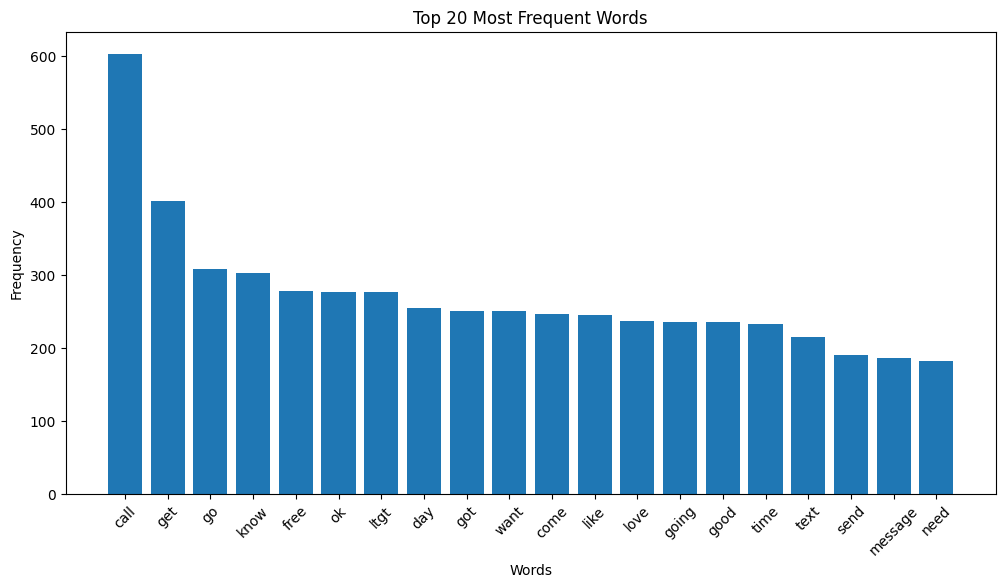

In [48]:
# VISUALIZATION 1: Most Frequent Words
all_words = " ".join(df['clean_message']).split()

word_freq = Counter(all_words)

# Top 20 most common words
common_words = word_freq.most_common(20)

words = [word for word, freq in common_words]
freqs = [freq for word, freq in common_words]

plt.figure(figsize=(12, 6))
plt.bar(words, freqs)
plt.xticks(rotation=45)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 20 Most Frequent Words")
plt.show()

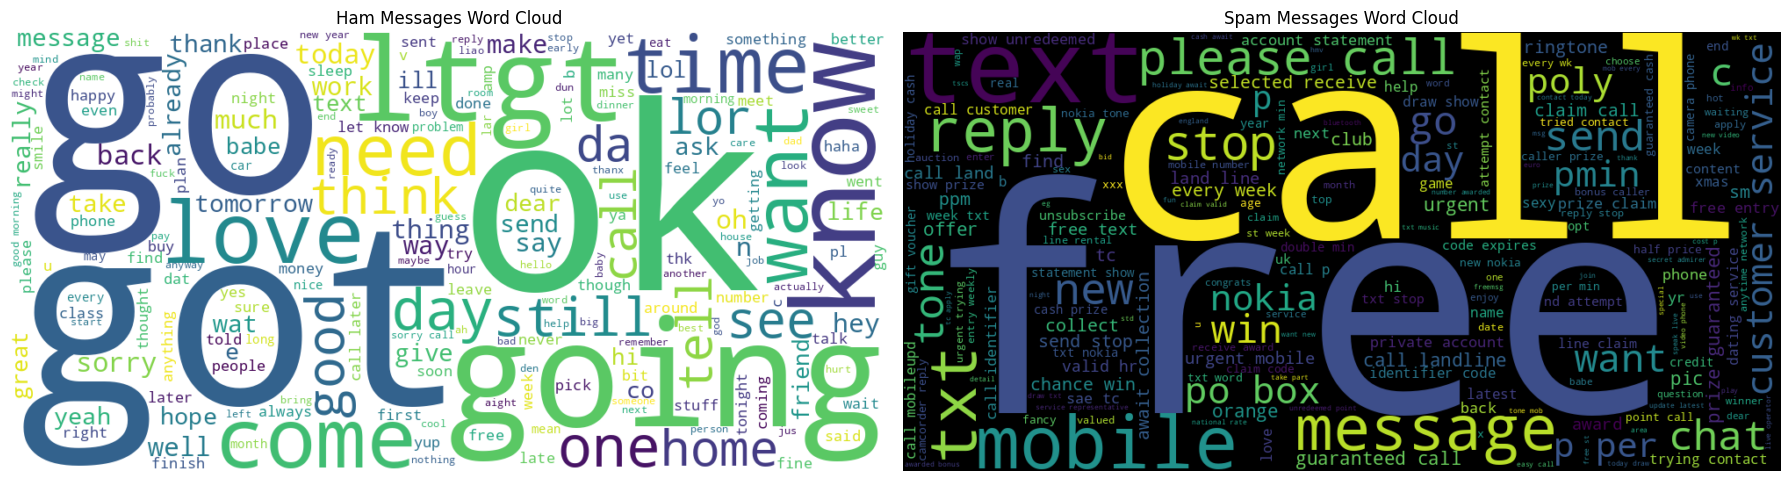

In [49]:
# VISUALIZATION 2: WORD CLOUDS FOR HAM AND SPAM

# Separate ham and spam messages
ham_words = " ".join(
    df[df['label'] == 0]['clean_message']
).split()

spam_words = " ".join(
    df[df['label'] == 1]['clean_message']
).split()

# Create word clouds
ham_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(" ".join(ham_words))

spam_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='black'
).generate(" ".join(spam_words))

# DISPLAY BOTH WORD CLOUDS
plt.figure(figsize=(18, 8))

# HAM WORD CLOUD
plt.subplot(1, 2, 1)
plt.imshow(ham_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Ham Messages Word Cloud")

# SPAM WORD CLOUD
plt.subplot(1, 2, 2)
plt.imshow(spam_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Spam Messages Word Cloud")

plt.tight_layout()
plt.show()

In [50]:
# TRAIN TEST SPLIT (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_message'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))


Training Samples: 4457
Testing Samples: 1115


In [51]:
# Tokenization
MAX_WORDS = 5000

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")

# Fit only on training data
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [52]:
# PERCENTILE-BASED PADDING
# Calculate sequence lengths
sequence_lengths = [len(seq) for seq in X_train_seq]

# Using 95th percentile to avoid very long sequences
MAX_LENGTH = int(np.percentile(sequence_lengths, 95))

print("\nChosen Max Sequence Length (95th Percentile):", MAX_LENGTH)

# Apply padding
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LENGTH,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LENGTH,
    padding='post',
    truncating='post'
)


Chosen Max Sequence Length (95th Percentile): 18


In [56]:
# CALLBACKS
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3
)

checkpoint = ModelCheckpoint(
      filepath="best_model.keras",
      monitor="val_accuracy",
      save_best_only=True,
      verbose=1
)

callbacks = [early_stop, reduce_lr, checkpoint]

In [63]:
EPOCHS = 20

embedding_dim = 64

model1 = Sequential([
    Input(shape=(MAX_LENGTH,)),
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=embedding_dim,
    ),

    SimpleRNN(64),

    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

model1.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model1.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 18, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,321 (1.25 MB)

 Trainable params: 328,321 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

In [68]:
# TRAIN MODEL 1
start_time = time.time()
history1 = model1.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)
end_time = time.time()
model1_training_time = end_time - start_time

Epoch 1/20
110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9952 - loss: 0.0244
Epoch 1: val_accuracy did not improve from 0.97646
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9950 - loss: 0.0266 - val_accuracy: 0.9675 - val_loss: 0.1028 - learning_rate: 5.0000e-04
Epoch 2/20
111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9951 - loss: 0.0231
Epoch 2: val_accuracy did not improve from 0.97646
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9958 - loss: 0.0188 - val_accuracy: 0.9753 - val_loss: 0.0893 - learning_rate: 5.0000e-04
Epoch 3/20
110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9966 - loss: 0.0154
Epoch 3: val_accuracy did not improve from 0.97646
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9978 - loss: 0.0118 - val_accuracy: 0.9720 - val_loss: 0.1030 - learning_rate: 5.0000e-04
Epoch 4/20
107/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9943 - loss: 0.0142
Epoch 4: val_accuracy did not improve from 0.97646
112/112 ━━━

In [69]:
# MODEL 2 - LSTM

model2 = Sequential([
    Input(shape=(MAX_LENGTH,)),
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=embedding_dim,
    ),

    LSTM(64),

    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

# Compile model
model2.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Show summary
model2.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 18, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353,089 (1.35 MB)

 Trainable params: 353,089 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

In [70]:
# TRAIN MODEL 2
start_time = time.time()
history2 = model2.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)
end_time = time.time()
model2_training_time = end_time - start_time


Epoch 1/20
110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8800 - loss: 0.3447
Epoch 1: val_accuracy did not improve from 0.97646
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9259 - loss: 0.2176 - val_accuracy: 0.9709 - val_loss: 0.1212 - learning_rate: 0.0010
Epoch 2/20
110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9911 - loss: 0.0384
Epoch 2: val_accuracy did not improve from 0.97646
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9891 - loss: 0.0467 - val_accuracy: 0.9720 - val_loss: 0.0829 - learning_rate: 0.0010
Epoch 3/20
111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9966 - loss: 0.0208
Epoch 3: val_accuracy did not improve from 0.97646
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9955 - loss: 0.0215 - val_accuracy: 0.9697 - val_loss: 0.1188 - learning_rate: 0.0010
Epoch 4/20
111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9970 - loss: 0.0160
Epoch 4: val_accuracy did not improve from 0.97646
112/112 ━━━━━━━━━━━━━━

In [73]:
# MODEL 3 - WORD2VEC + LSTM

# Tokenized sentences for Word2Vec
sentences = [text.split() for text in X_train]

# Train Word2Vec model
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)

# Create embedding matrix
embedding_dim_w2v = 100

word_index = tokenizer.word_index

embedding_matrix = np.zeros(
    (MAX_WORDS, embedding_dim_w2v)
)

for word, i in word_index.items():

    if i >= MAX_WORDS:
        continue

    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

In [75]:
# BUILD MODEL 3
model3 = Sequential([
    Input(shape=(MAX_LENGTH,)),
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=embedding_dim_w2v,
        weights=[embedding_matrix],
        trainable=False
    ),

    LSTM(64),

    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

model3.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model3.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 18, 100)        │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 542,305 (2.07 MB)

 Trainable params: 42,305 (165.25 KB)

 Non-trainable params: 500,000 (1.91 MB)

In [76]:
# TRAIN MODEL 3
start_time = time.time()
history3 = model3.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)
end_time = time.time()
model3_training_time = end_time - start_time

Epoch 1/20
110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8628 - loss: 0.4623
Epoch 1: val_accuracy did not improve from 0.97646
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.8676 - loss: 0.3579 - val_accuracy: 0.8430 - val_loss: 0.3474 - learning_rate: 0.0010
Epoch 2/20
111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8624 - loss: 0.2908
Epoch 2: val_accuracy did not improve from 0.97646
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8668 - loss: 0.2842 - val_accuracy: 0.8509 - val_loss: 0.3194 - learning_rate: 0.0010
Epoch 3/20
109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8686 - loss: 0.2928
Epoch 3: val_accuracy did not improve from 0.97646
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8738 - loss: 0.2800 - val_accuracy: 0.8475 - val_loss: 0.3195 - learning_rate: 0.0010


In [77]:
# EVALUATION FUNCTION
def evaluate_model(model, X_test, y_test, model_name):

    predictions = model.predict(X_test)

    y_pred = (predictions > 0.5).astype(int)

    accuracy = accuracy_score(y_test, y_pred)

    print(f"\n{model_name} Accuracy:", accuracy)

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return accuracy, y_pred

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

Simple RNN Accuracy: 0.9757847533632287

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.98      0.84      0.90       149

    accuracy                           0.98      1115
   macro avg       0.98      0.92      0.94      1115
weighted avg       0.98      0.98      0.97      1115



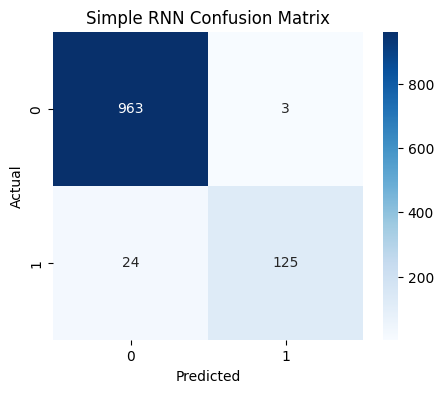

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

LSTM Accuracy: 0.9820627802690582

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.99      0.87      0.93       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



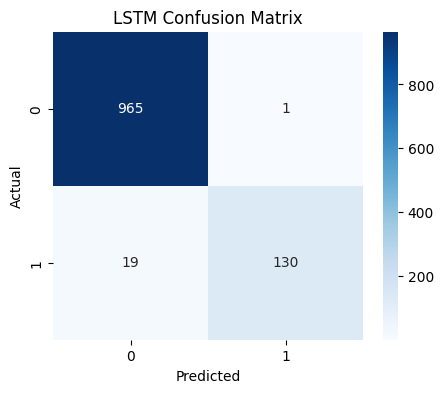

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

Word2Vec + LSTM Accuracy: 0.8663677130044843

Classification Report:

              precision    recall  f1-score   support

           0       0.87      1.00      0.93       966
           1       0.00      0.00      0.00       149

    accuracy                           0.87      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.75      0.87      0.80      1115



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


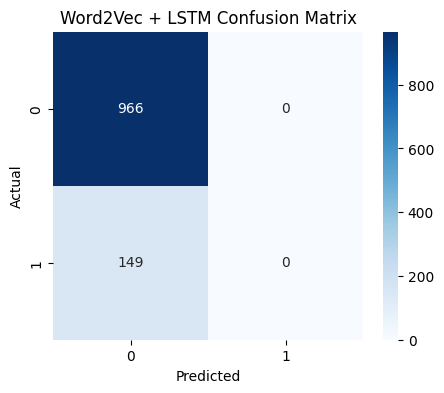

In [78]:
# EVALUATE MODELS
# =========================================================
acc1, pred1 = evaluate_model(
    model1,
    X_test_pad,
    y_test,
    "Simple RNN"
)

acc2, pred2 = evaluate_model(
    model2,
    X_test_pad,
    y_test,
    "LSTM"
)

acc3, pred3 = evaluate_model(
    model3,
    X_test_pad,
    y_test,
    "Word2Vec + LSTM"
)

In [79]:
# TRAINING CURVE FUNCTION
def plot_history(history, title):

    # Accuracy Plot
    plt.figure(figsize=(12, 5))

    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

    plt.title(f'{title} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')

    plt.legend()
    plt.show()

    # Loss Plot
    plt.figure(figsize=(12, 5))

    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')

    plt.title(f'{title} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    plt.legend()
    plt.show()

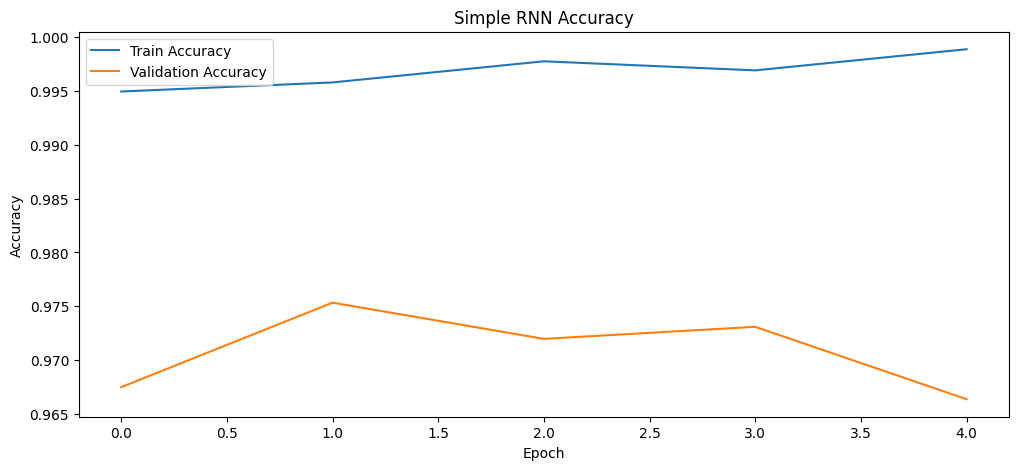

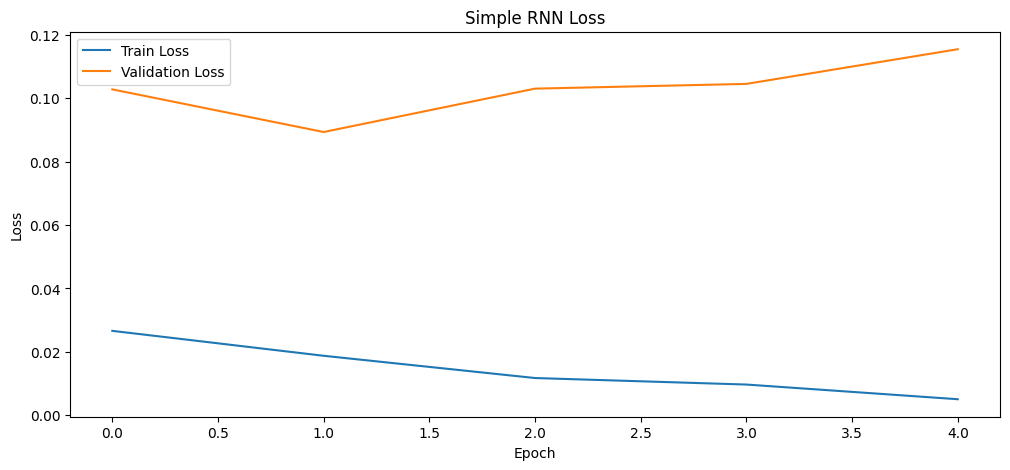

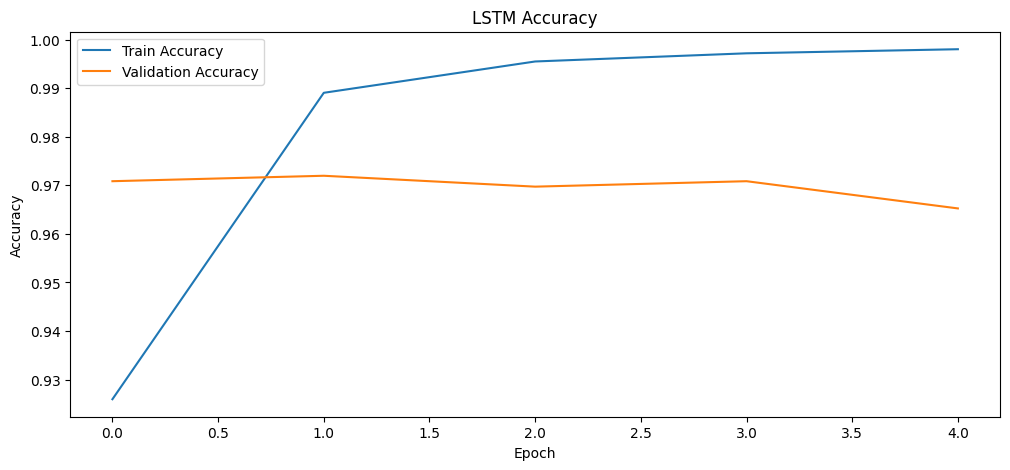

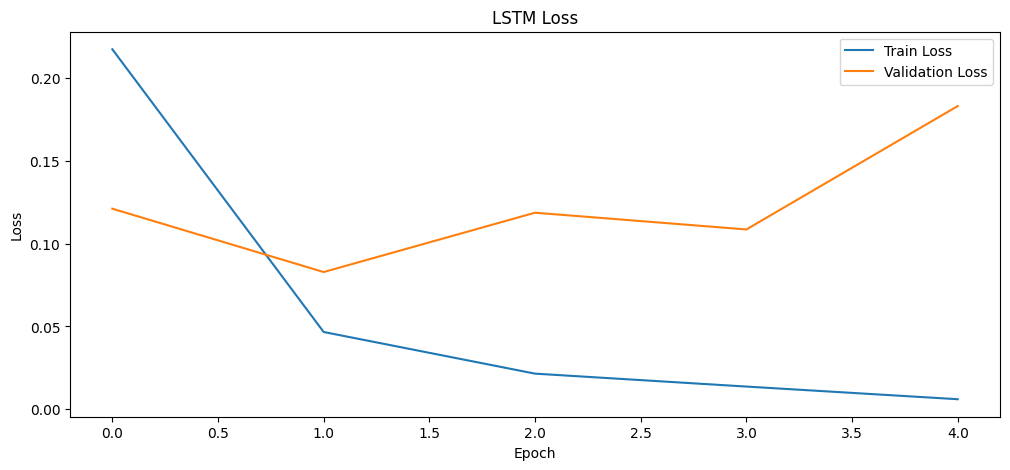

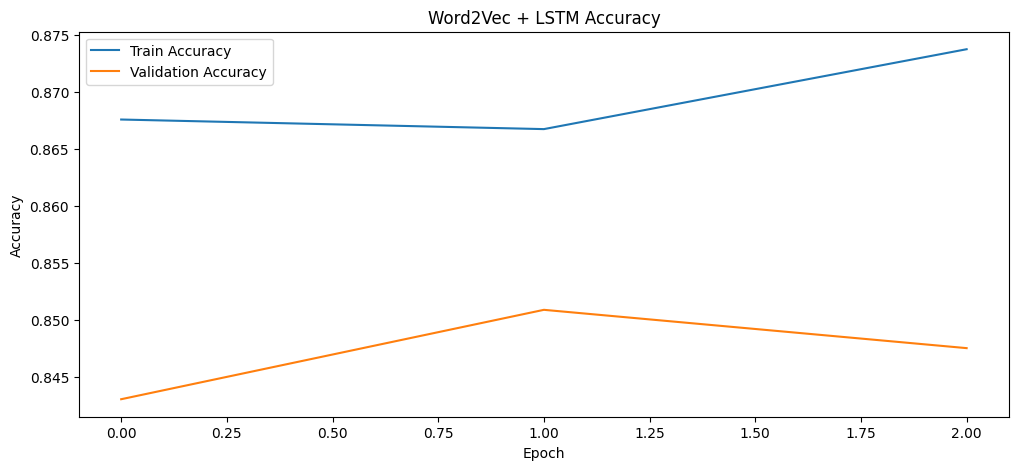

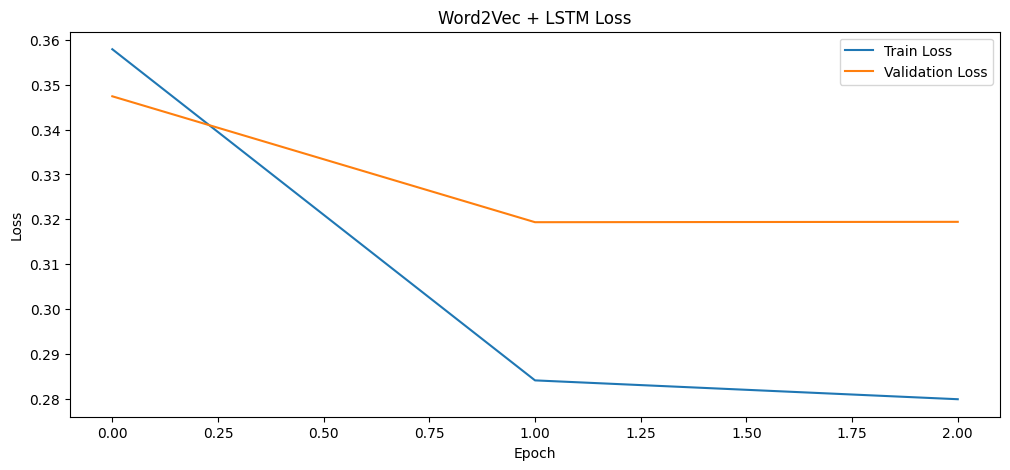

In [80]:
# VISUALIZE TRAINING
plot_history(history1, "Simple RNN")
plot_history(history2, "LSTM")
plot_history(history3, "Word2Vec + LSTM")

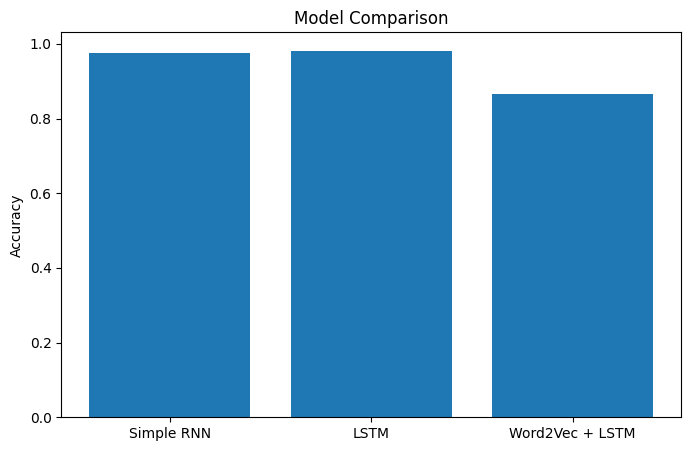

In [81]:
# MODEL COMPARISON
model_names = [
    'Simple RNN',
    'LSTM',
    'Word2Vec + LSTM'
]

accuracies = [
    acc1,
    acc2,
    acc3
]

plt.figure(figsize=(8, 5))

plt.bar(model_names, accuracies)

plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.show()

In [82]:
# ERROR ANALYSIS
def show_errors(model, X_test, y_test, raw_texts, model_name):

    predictions = model.predict(X_test)

    y_pred = (predictions > 0.5).astype(int).flatten()

    incorrect = np.where(y_pred != y_test)[0]

    print(f"\n===== Incorrect Predictions ({model_name}) =====\n")

    for i in incorrect[:3]:

        print("Message:")
        print(raw_texts.iloc[i])

        print("Actual:", y_test.iloc[i])
        print("Predicted:", y_pred[i])

        print("-" * 50)

show_errors(
    model3,
    X_test_pad,
    y_test.reset_index(drop=True),
    X_test.reset_index(drop=True),
    "Word2Vec + LSTM"
)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

===== Incorrect Predictions (Word2Vec + LSTM) =====

Message:
cash prize claim call
Actual: 1
Predicted: 0
--------------------------------------------------
Message:
unsubscribed service get ton sexy babe hunk straight phone go subscription
Actual: 1
Predicted: 0
--------------------------------------------------
Message:
want get laid nite want real dogging location sent direct mobile join uk largest dogging network txt park nyt eca lp message
Actual: 1
Predicted: 0
--------------------------------------------------


In [98]:
# REAL-TIME PREDICTION FUNCTION
def predict_sms(text):

    cleaned = clean_text(text)

    seq = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(
        seq,
        maxlen=MAX_LENGTH,
        padding='post'
    )

    # Use model1 for prediction as requested
    prediction = model1.predict(padded)[0][0]

    label = "SPAM" if prediction > 0.5 else "HAM"

    # Display confidence correctly based on the predicted label
    confidence = prediction if label == "SPAM" else (1 - prediction)

    return f"{label} (Confidence: {confidence:.4f})"


In [99]:
# GRADIO GUI
interface = gr.Interface(
    fn=predict_sms,
    inputs=gr.Textbox(
        lines=4,
        placeholder="Enter SMS text here..."
    ),
    outputs="text",
    title="Spam vs Ham SMS Classifier",
    description="Enter a message to classify it as SPAM or HAM."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8844e34cf183ea3b8f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
